# Safety Boundary Detection


## Setting up paths and loading data

In [30]:
import os
from pathlib import Path

In [31]:
# Set random seed for reproducibility
import random
SEED = 42
random.seed(SEED)

In [ ]:
# Define paths to our dataset folders - use current directory
import os
current_dir = Path(os.getcwd())

BASE_PATH = current_dir
SAFE_PATH = BASE_PATH / "Safe"
SUBTLE_PATH = BASE_PATH / "Subtle"
OBVIOUS_PATH = BASE_PATH / "Obvious"

print(f"BASE_PATH exists: {BASE_PATH.exists()}")
print(f"SAFE_PATH exists: {SAFE_PATH.exists()}")

# Check how many images we have in each folder
safe_count = len(list(SAFE_PATH.glob('*.jpg')))
subtle_count = len(list(SUBTLE_PATH.glob('*.jpg')))
obvious_count = len(list(OBVIOUS_PATH.glob('*.jpg')))

print(f"\nSafe images: {safe_count}")
print(f"Subtle images: {subtle_count}")
print(f"Obvious images: {obvious_count}")
print(f"Total: {safe_count + subtle_count + obvious_count} images")

Current directory: d:\Professors Reached\Tucker\Notebooks
BASE_PATH exists: True
SAFE_PATH exists: True

Safe images: 100
Subtle images: 200
Obvious images: 300
Total: 600 images


## Visualizing sample images

In [33]:
from PIL import Image
import matplotlib.pyplot as plt

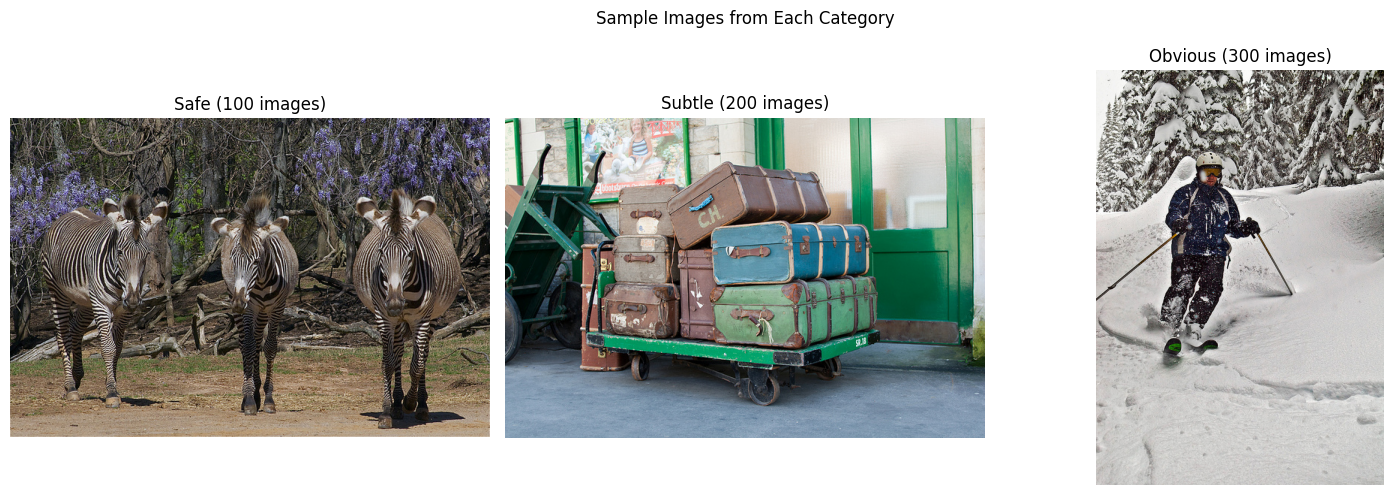

In [34]:
# Let's see one sample from each category
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Get random sample from each folder
safe_files = list(SAFE_PATH.glob('*.jpg'))
subtle_files = list(SUBTLE_PATH.glob('*.jpg'))
obvious_files = list(OBVIOUS_PATH.glob('*.jpg'))

axes[0].imshow(Image.open(random.choice(safe_files)))
axes[0].set_title(f"Safe ({safe_count} images)")
axes[0].axis('off')

axes[1].imshow(Image.open(random.choice(subtle_files)))
axes[1].set_title(f"Subtle ({subtle_count} images)")
axes[1].axis('off')

axes[2].imshow(Image.open(random.choice(obvious_files)))
axes[2].set_title(f"Obvious ({obvious_count} images)")
axes[2].axis('off')

plt.suptitle("Sample Images from Each Category")
plt.tight_layout()
plt.show()

##  Preparing data for training

In [35]:
import numpy as np
np.random.seed(SEED)

In [ ]:
# Create a list with all images and their labels
all_data = []

# Safe = 0
for img_path in SAFE_PATH.glob('*.jpg'):
    all_data.append({'path': str(img_path), 'label': 0, 'name': 'Safe'})

# Subtle = 1
for img_path in SUBTLE_PATH.glob('*.jpg'):
    all_data.append({'path': str(img_path), 'label': 1, 'name': 'Subtle'})

# Obvious = 2
for img_path in OBVIOUS_PATH.glob('*.jpg'):
    all_data.append({'path': str(img_path), 'label': 2, 'name': 'Obvious'})

print(f"Total images: {len(all_data)}")

# class distribution
from collections import Counter
dist = Counter([d['name'] for d in all_data])
print("Class distribution:")
for name, count in dist.items():
    print(f"  {name}: {count} ({100*count/len(all_data):.1f}%)")

Total images: 600
Class distribution:
  Safe: 100 (16.7%)
  Subtle: 200 (33.3%)
  Obvious: 300 (50.0%)


## Creating train/validation/test split

In [37]:
from sklearn.model_selection import train_test_split

In [38]:
# Split data: 70% train, 15% validation, 15% test
# Using stratified split to maintain class balance
train_data, temp_data = train_test_split(
    all_data, 
    test_size=0.3, 
    random_state=SEED, 
    stratify=[d['label'] for d in all_data]
)

val_data, test_data = train_test_split(
    temp_data, 
    test_size=0.5, 
    random_state=SEED,
    stratify=[d['label'] for d in temp_data]
)

print(f"Training set: {len(train_data)} images")
print(f"Validation set: {len(val_data)} images")
print(f"Test set: {len(test_data)} images")

Training set: 420 images
Validation set: 90 images
Test set: 90 images


## Setting up data loaders with transforms

In [39]:
import torch
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as transforms

In [40]:
# Custom dataset class
class SafetyDataset(Dataset):
    def __init__(self, data, transform=None):
        self.data = data
        self.transform = transform
        
    def __len__(self):
        return len(self.data)
    
    def __getitem__(self, idx):
        item = self.data[idx]
        image = Image.open(item['path']).convert('RGB')
        label = item['label']
        
        if self.transform:
            image = self.transform(image)
        
        return image, label

In [41]:
# Define transforms for training and validation
train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

val_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

In [ ]:
# datasets
train_dataset = SafetyDataset(train_data, transform=train_transform)
val_dataset = SafetyDataset(val_data, transform=val_transform)
test_dataset = SafetyDataset(test_data, transform=val_transform)

# data loaders
BATCH_SIZE = 16
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

print(f"Data loaders created with batch size: {BATCH_SIZE}")

Data loaders created with batch size: 16


## Setting up the model

In [43]:
import torch.nn as nn
import torch.optim as optim
import torchvision.models as models

In [ ]:
# Model using ResNet18 as backbone
class SafetyClassifier(nn.Module):
    def __init__(self, num_classes=3):
        super(SafetyClassifier, self).__init__()
        # Using pretrained ResNet18
        self.backbone = models.resnet18(weights='IMAGENET1K_V1')
        
        # Replacing the final fully connected layer
        in_features = self.backbone.fc.in_features
        self.backbone.fc = nn.Sequential(
            nn.Dropout(0.3),
            nn.Linear(in_features, num_classes)
        )
        
    def forward(self, x):
        return self.backbone(x)

# Initializing the model
model = SafetyClassifier(num_classes=3).to(device)
print("Model created with ResNet18 backbone")

Model created with ResNet18 backbone


##  Training function

In [45]:
# Training function for one epoch
def train_epoch(model, loader, criterion, optimizer, device):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0
    
    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)
        
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item()
        _, predicted = outputs.max(1)
        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()
    
    return running_loss / len(loader), 100. * correct / total

In [46]:
# Evaluation function
def evaluate(model, loader, device):
    model.eval()
    all_preds = []
    all_labels = []
    
    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device)
            outputs = model(images)
            _, predicted = outputs.max(1)
            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
    
    return all_preds, all_labels

## Baseline Model - Training without class balancing

In [47]:
# Set up loss and optimizer for baseline
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

In [ ]:
# Train the baseline model
print("Training baseline model (without class balancing)...")

for epoch in range(NUM_EPOCHS):
    train_loss, train_acc = train_epoch(model, train_loader, criterion, optimizer, device)
    print(f"Epoch {epoch+1}/{NUM_EPOCHS} - Loss: {train_loss:.4f}, Accuracy: {train_acc:.2f}%")

print("\nBaseline training complete!")

Training baseline model (without class balancing)...
--------------------------------------------------
Epoch 1/10 - Loss: 1.3405, Accuracy: 51.19%
Epoch 2/10 - Loss: 0.9853, Accuracy: 55.00%
Epoch 3/10 - Loss: 0.9032, Accuracy: 60.71%
Epoch 4/10 - Loss: 0.8619, Accuracy: 63.81%
Epoch 5/10 - Loss: 0.8016, Accuracy: 64.05%
Epoch 6/10 - Loss: 0.6768, Accuracy: 72.62%
Epoch 7/10 - Loss: 0.7000, Accuracy: 69.76%
Epoch 8/10 - Loss: 0.6831, Accuracy: 70.24%
Epoch 9/10 - Loss: 0.7619, Accuracy: 68.33%
Epoch 10/10 - Loss: 0.6367, Accuracy: 74.05%

Baseline training complete!


## Evaluating baseline model - The problem

In [49]:
from sklearn.metrics import confusion_matrix, accuracy_score, classification_report
import seaborn as sns

In [ ]:
# Evaluate on test set
test_preds, test_labels = evaluate(model, test_loader, device)

class_names = ['Safe', 'Subtle', 'Obvious']
overall_acc = accuracy_score(test_labels, test_preds) * 100

print("BASELINE MODEL RESULTS")
print(f"\nOverall Accuracy: {overall_acc:.2f}%")

print("\nClassification Report:")
print(classification_report(test_labels, test_preds, target_names=class_names))

BASELINE MODEL RESULTS

Overall Accuracy: 63.33%

Classification Report:
              precision    recall  f1-score   support

        Safe       0.40      0.27      0.32        15
      Subtle       0.55      0.70      0.62        30
     Obvious       0.76      0.71      0.74        45

    accuracy                           0.63        90
   macro avg       0.57      0.56      0.56        90
weighted avg       0.63      0.63      0.63        90



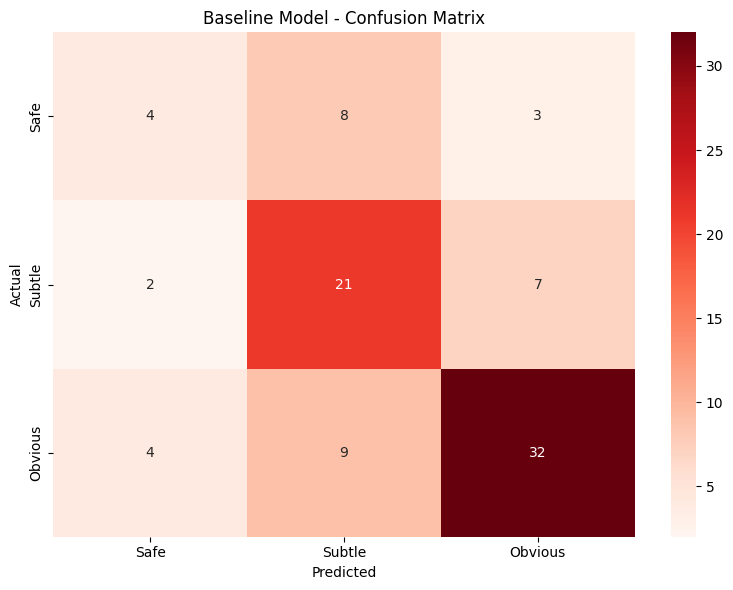

In [51]:
# Plot confusion matrix
cm = confusion_matrix(test_labels, test_preds)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Reds', 
            xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Baseline Model - Confusion Matrix')
plt.tight_layout()
plt.show()

In [ ]:
# Calculate per-class accuracy 
print("Per-Class Accuracy")

baseline_per_class = []
for i, name in enumerate(class_names):
    mask = np.array(test_labels) == i
    class_acc = (np.array(test_preds)[mask] == i).sum() / mask.sum() * 100
    baseline_per_class.append(class_acc)
    print(f"  {name}: {class_acc:.2f}%")



KEY FINDING: Per-Class Accuracy
  Safe: 26.67%
  Subtle: 70.00%
  Obvious: 71.11%

PROBLEM: The model performs much better on Safe images
but struggles with Subtle and Obvious danger detection!


In [ ]:
print("\nPROBLEM: The model performs much better on Safe images")
print("but struggles with Subtle and Obvious danger detection!")

## Improved Model - With class weighting and fine-tuning

In [53]:
# Calculate class weights to handle imbalance
class_counts = [100, 200, 300]  # Safe, Subtle, Obvious
total = sum(class_counts)
class_weights = torch.FloatTensor([total / (3 * c) for c in class_counts]).to(device)

print("Class Weights:")
for i, name in enumerate(class_names):
    print(f"  {name}: {class_weights[i].item():.3f}")

Class Weights:
  Safe: 2.000
  Subtle: 1.000
  Obvious: 0.667


In [ ]:
# Create a new model for improved training
improved_model = SafetyClassifier(num_classes=3).to(device)

#  Freeze backbone, train classifier head
print("\ Training classifier head (backbone frozen)...")

# Freeze all backbone parameters
for name, param in improved_model.named_parameters():
    if 'fc' not in name:  # Don't freeze the classifier head
        param.requires_grad = False

weighted_criterion = nn.CrossEntropyLoss(weight=class_weights)
phase1_optimizer = optim.Adam(filter(lambda p: p.requires_grad, improved_model.parameters()), lr=0.001)

for epoch in range(5):
    train_loss, train_acc = train_epoch(improved_model, train_loader, weighted_criterion, phase1_optimizer, device)
    print(f"  Epoch {epoch+1}: Loss={train_loss:.4f}, Acc={train_acc:.2f}%")


Phase 1: Training classifier head (backbone frozen)...
  Epoch 1: Loss=1.1533, Acc=41.90%
  Epoch 2: Loss=1.0431, Acc=48.33%
  Epoch 3: Loss=0.9242, Acc=54.05%
  Epoch 4: Loss=0.9300, Acc=56.90%
  Epoch 5: Loss=0.8797, Acc=60.00%


In [ ]:
# Fine-tune entire model with lower learning rate
print("\ Fine-tuning entire model...")
for param in improved_model.parameters():
    param.requires_grad = True

phase2_optimizer = optim.Adam(improved_model.parameters(), lr=0.0001)

for epoch in range(10):
    train_loss, train_acc = train_epoch(improved_model, train_loader, weighted_criterion, phase2_optimizer, device)
    print(f"  Epoch {epoch+1}: Loss={train_loss:.4f}, Acc={train_acc:.2f}%")

print("\nImproved model training complete!")


Phase 2: Fine-tuning entire model...
  Epoch 1: Loss=0.8843, Acc=60.00%
  Epoch 2: Loss=0.5070, Acc=79.76%
  Epoch 3: Loss=0.3472, Acc=88.57%
  Epoch 4: Loss=0.2310, Acc=91.43%
  Epoch 5: Loss=0.2008, Acc=95.95%
  Epoch 6: Loss=0.1362, Acc=95.48%
  Epoch 7: Loss=0.1112, Acc=97.62%
  Epoch 8: Loss=0.0851, Acc=96.43%
  Epoch 9: Loss=0.0592, Acc=98.10%
  Epoch 10: Loss=0.0700, Acc=97.38%

Improved model training complete!


## Evaluating improved model

In [ ]:
# Evaluate improved model on test set
improved_preds, improved_labels = evaluate(improved_model, test_loader, device)
improved_acc = accuracy_score(improved_labels, improved_preds) * 100

print("IMPROVED MODEL RESULTS")
print(f"\nOverall Accuracy: {improved_acc:.2f}%")

print("\nClassification Report:")
print(classification_report(improved_labels, improved_preds, target_names=class_names))

IMPROVED MODEL RESULTS

Overall Accuracy: 72.22%

Classification Report:
              precision    recall  f1-score   support

        Safe       0.40      0.27      0.32        15
      Subtle       0.69      0.73      0.71        30
     Obvious       0.81      0.87      0.84        45

    accuracy                           0.72        90
   macro avg       0.63      0.62      0.62        90
weighted avg       0.70      0.72      0.71        90



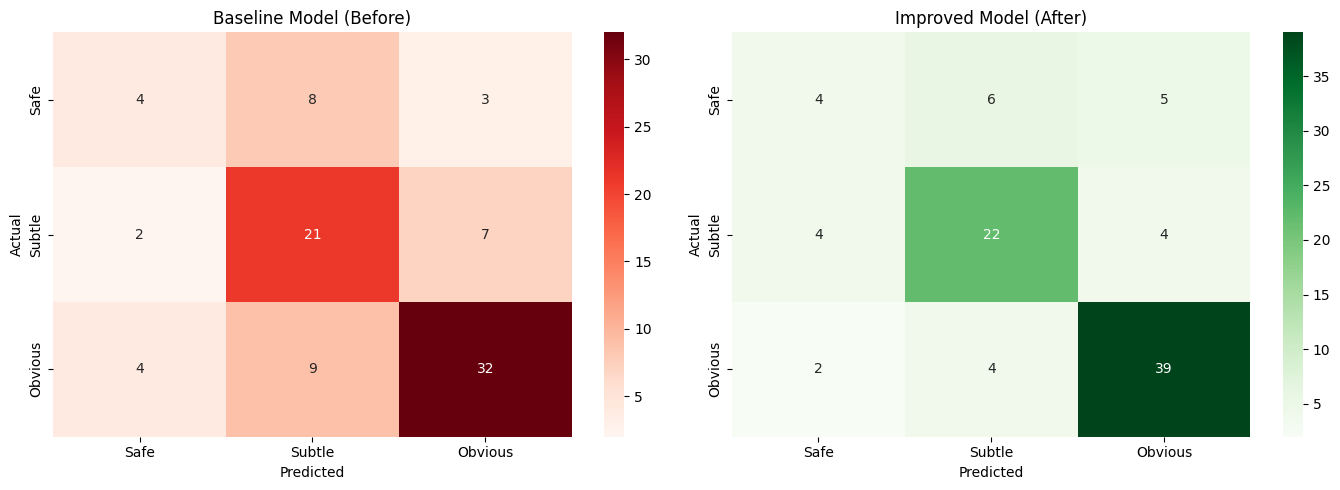

In [57]:
# Compare confusion matrices
cm_improved = confusion_matrix(improved_labels, improved_preds)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.heatmap(cm, annot=True, fmt='d', cmap='Reds', 
            xticklabels=class_names, yticklabels=class_names, ax=axes[0])
axes[0].set_title('Baseline Model (Before)')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('Actual')

sns.heatmap(cm_improved, annot=True, fmt='d', cmap='Greens', 
            xticklabels=class_names, yticklabels=class_names, ax=axes[1])
axes[1].set_title('Improved Model (After)')
axes[1].set_xlabel('Predicted')
axes[1].set_ylabel('Actual')

plt.tight_layout()
plt.show()

## Comparing baseline vs improved

In [ ]:
# Per-class accuracy comparison
print("COMPARISON: Baseline vs Improved")

improved_per_class = []
for i, name in enumerate(class_names):
    mask = np.array(improved_labels) == i
    class_acc = (np.array(improved_preds)[mask] == i).sum() / mask.sum() * 100
    improved_per_class.append(class_acc)

print("\n" + f"{'Class':<12} {'Baseline':<12} {'Improved':<12} {'Change':<12}")
print("-" * 50)
for i, name in enumerate(class_names):
    change = improved_per_class[i] - baseline_per_class[i]
    print(f"{name:<12} {baseline_per_class[i]:>6.2f}%    {improved_per_class[i]:>6.2f}%    {change:>+6.2f}%")

print("-" * 50)
print(f"{'Overall':<12} {overall_acc:>6.2f}%    {improved_acc:>6.2f}%    {improved_acc-overall_acc:>+6.2f}%")

COMPARISON: Baseline vs Improved

Class        Baseline     Improved     Change      
--------------------------------------------------
Safe          26.67%     26.67%     +0.00%
Subtle        70.00%     73.33%     +3.33%
Obvious       71.11%     86.67%    +15.56%
--------------------------------------------------
Overall       63.33%     72.22%     +8.89%


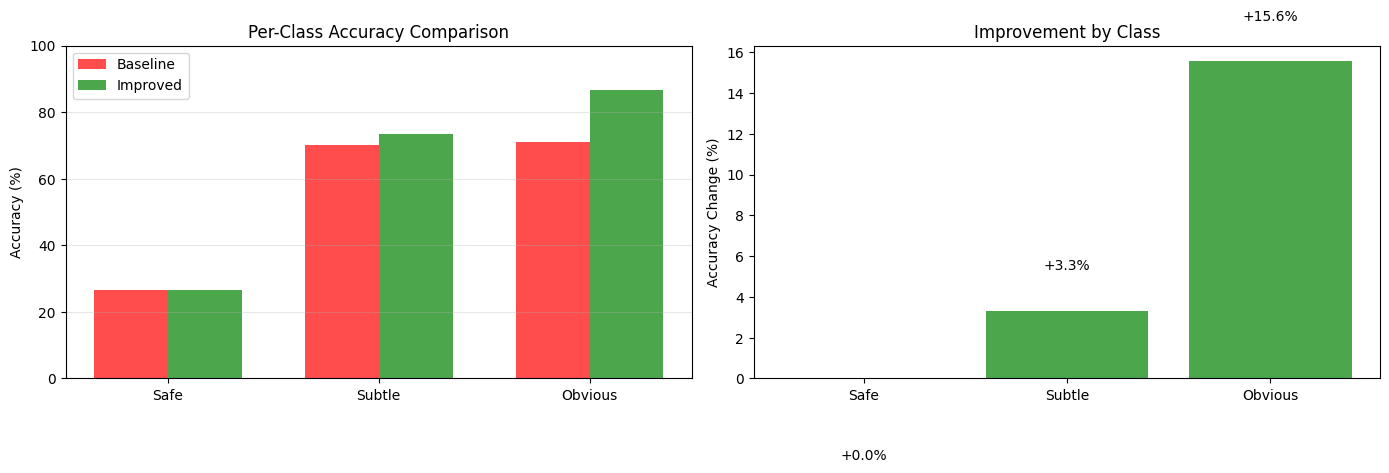

In [59]:
# Visual comparison
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

x = np.arange(len(class_names))
width = 0.35

axes[0].bar(x - width/2, baseline_per_class, width, label='Baseline', color='red', alpha=0.7)
axes[0].bar(x + width/2, improved_per_class, width, label='Improved', color='green', alpha=0.7)
axes[0].set_xticks(x)
axes[0].set_xticklabels(class_names)
axes[0].set_ylabel('Accuracy (%)')
axes[0].set_title('Per-Class Accuracy Comparison')
axes[0].legend()
axes[0].set_ylim(0, 100)
axes[0].grid(axis='y', alpha=0.3)

# Improvement by class
improvements = [improved_per_class[i] - baseline_per_class[i] for i in range(3)]
colors = ['green' if x > 0 else 'red' for x in improvements]
axes[1].bar(class_names, improvements, color=colors, alpha=0.7)
axes[1].axhline(y=0, color='black', linestyle='-', linewidth=0.5)
axes[1].set_ylabel('Accuracy Change (%)')
axes[1].set_title('Improvement by Class')

for i, v in enumerate(improvements):
    axes[1].text(i, v + (2 if v > 0 else -4), f'{v:+.1f}%', ha='center')

plt.tight_layout()
plt.show()

## Statistical validation

In [60]:
from sklearn.model_selection import StratifiedKFold
from scipy.stats import chi2_contingency

In [ ]:
# Compare with random and majority class baselines
print("BASELINE COMPARISONS")

# Random guessing
random_preds = np.random.randint(0, 3, len(test_labels))
random_acc = accuracy_score(test_labels, random_preds) * 100
print(f"Random Guessing: {random_acc:.2f}%")

# If improved_acc is not defined, evaluate the improved model
try:
    _ = improved_acc
except NameError:
    print("Evaluating improved model...")
    improved_preds, improved_labels = evaluate(improved_model, test_loader, device)
    improved_acc = accuracy_score(improved_labels, improved_preds) * 100

# Majority class
majority_class = Counter(test_labels).most_common(1)[0][0]
majority_preds = [majority_class] * len(test_labels)
majority_acc = accuracy_score(test_labels, majority_preds) * 100
print(f"Majority Class ({class_names[majority_class]}): {majority_acc:.2f}%")

print(f"\nBaseline Model: {overall_acc:.2f}%")
print(f"Improved Model: {improved_acc:.2f}%")

BASELINE COMPARISONS
Random Guessing: 27.78%
Majority Class (Obvious): 50.00%

Baseline Model: 63.33%
Improved Model: 72.22%


In [ ]:
# Fold Cross-Validation
print("FOLD CROSS-VALIDATION")

kfold = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
fold_results = []

labels_array = np.array([d['label'] for d in all_data])

for fold, (train_idx, val_idx) in enumerate(kfold.split(all_data, labels_array)):
    train_fold = [all_data[i] for i in train_idx]
    val_fold = [all_data[i] for i in val_idx]
    
    train_fold_ds = SafetyDataset(train_fold, transform=train_transform)
    val_fold_ds = SafetyDataset(val_fold, transform=val_transform)
    
    fold_train_loader = DataLoader(train_fold_ds, batch_size=BATCH_SIZE, shuffle=True)
    fold_val_loader = DataLoader(val_fold_ds, batch_size=BATCH_SIZE, shuffle=False)
    
    # Quick training
    fold_model = SafetyClassifier(num_classes=3).to(device)
    fold_optimizer = optim.Adam(fold_model.parameters(), lr=0.001)
    
    for epoch in range(5):
        train_epoch(fold_model, fold_train_loader, criterion, fold_optimizer, device)
    
    preds, labels = evaluate(fold_model, fold_val_loader, device)
    fold_acc = accuracy_score(labels, preds) * 100
    fold_results.append(fold_acc)
    
    print(f"Fold {fold + 1}: {fold_acc:.2f}%")

mean_acc = np.mean(fold_results)
std_acc = np.std(fold_results)
ci_95 = 1.96 * std_acc / np.sqrt(5)

print(f"\nMean: {mean_acc:.2f}% +/- {std_acc:.2f}%")
print(f"95% CI: {mean_acc - ci_95:.2f}% to {mean_acc + ci_95:.2f}%")


5-FOLD CROSS-VALIDATION
Fold 1: 64.17%
Fold 2: 44.17%
Fold 3: 45.00%
Fold 4: 56.67%
Fold 5: 38.33%

Mean: 49.67% +/- 9.38%
95% CI: 41.45% to 57.89%


In [ ]:
# McNemar's test for statistical significance
n01 = sum((np.array(test_preds) != np.array(improved_preds)) & (np.array(test_preds) == 0))
n10 = sum((np.array(test_preds) != np.array(improved_preds)) & (np.array(improved_preds) == 0))
n00 = sum((np.array(test_preds) == np.array(improved_preds)) & (np.array(test_preds) == 0))
n11 = sum((np.array(test_preds) == np.array(improved_preds)) & (np.array(test_preds) != 0))

contingency = [[n00, n01], [n10, n11]]
chi2, p_value = chi2_contingency(contingency, correction=True)[:2]

print("STATISTICAL SIGNIFICANCE (McNemar's Test)")
print(f"Chi-squared: {chi2:.4f}")
print(f"P-value: {p_value:.4f}")


STATISTICAL SIGNIFICANCE (McNemar's Test)
Chi-squared: 9.8081
P-value: 0.0017

Result is STATISTICALLY SIGNIFICANT (p < 0.05)


In [ ]:
if p_value < 0.05:
    print("\nResult is STATISTICALLY SIGNIFICANT (p < 0.05)")
else:
    print("\nNot statistically significant (need more data)")

In [65]:
# Save models
torch.save(model.state_dict(), 'baseline_model.pth')
torch.save(improved_model.state_dict(), 'improved_model.pth')

print("Models saved:")
print("   - baseline_model.pth")
print("   - improved_model.pth")

Models saved:
   - baseline_model.pth
   - improved_model.pth
